# Error Analysis

This notebook analyzes prediction errors of the trained GCN model on
the QM9 test set, using 5 independently trained models (200 epochs,
same data split, different weight initializations) to distinguish
robust patterns from artifacts of a single training run.

Each section below investigates one specific question about model
behavior, using the combined predictions across the 5 models unless
stated otherwise.

In [1]:
import os

In [2]:
os.chdir("..")

In [3]:
import json
import matplotlib.pyplot as plt
from analysis.error_utils import load_and_predict_all_checkpoints

c:\Users\ericp\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. What does the error distribution look like?

Characterizes the overall shape of prediction error across the test
set: how errors are distributed, and whether the model shows a
systematic tendency to over- or under-estimate the target.

In [4]:
with open('docs/results/experiment_results.json') as f:
    experiment_results = json.load(f)

In [5]:
combined_df = load_and_predict_all_checkpoints(experiment_results, '200_epochs')

c:\Users\ericp\Desktop\Biblioteca\projects\Molecule_property_prediction_GNN\evaluation\checkpoint.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load

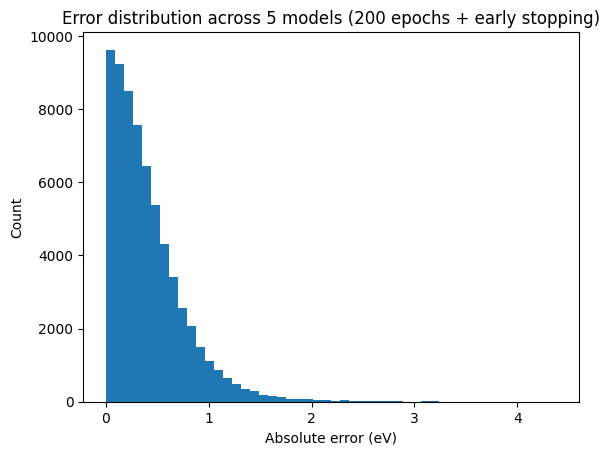

In [6]:
# Plot error distribution average

plt.hist(combined_df['error'], bins=50)
plt.xlabel('Absolute error (eV)')
plt.ylabel('Count')
plt.title('Error distribution across 5 models (200 epochs + early stopping)')
plt.savefig('docs/results/error_distribution_averaged.png')
plt.show()

In [7]:
combined_df['signed_error'] = combined_df['prediction'] - combined_df['ground_truth']

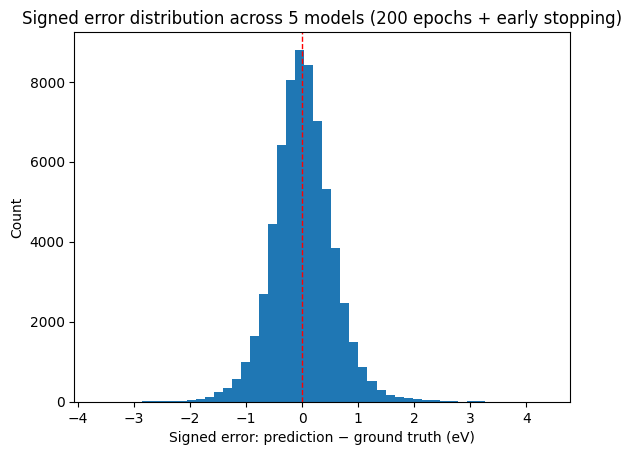

In [8]:
# Plot signed error distribution average

plt.hist(combined_df['signed_error'], bins=50)
plt.axvline(0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Signed error: prediction − ground truth (eV)')
plt.ylabel('Count')
plt.title('Signed error distribution across 5 models (200 epochs + early stopping)')
plt.savefig('docs/results/signed_error_distribution.png')
plt.show()

Intuitively, the error seems to be centered at 0, with no tendency to overestimate or underestimate. We will explore this further.

In [9]:
from scipy import stats

In [10]:
t_stat, p_value = stats.ttest_1samp(combined_df['signed_error'], 0)
print(f"t-statistic: {t_stat:.4f}, p-value: {p_value:.4f}")

t-statistic: 6.7769, p-value: 0.0000


The one-sample t-test indicates that the mean is statistically different from zero (p < 0.0001). 

However, given the large sample size, the test is highly sensitive to even small deviations from its assumptions. 

Therefore, we will compute additional metrics to further characterize the distribution.

In [11]:
print(f"Mean signed error: {combined_df['signed_error'].mean():.4f} eV")
print(f"As % of MAE: {100 * combined_df['signed_error'].mean() / combined_df['error'].mean():.2f}%")

Mean signed error: 0.0146 eV
As % of MAE: 3.53%


In [12]:
mean_signed_error_per_model = combined_df.groupby('run_id')['signed_error'].mean()
print(mean_signed_error_per_model)
print(f"Mean: {mean_signed_error_per_model.mean():.4f}, Std: {mean_signed_error_per_model.std():.4f}")

run_id
0    0.035501
1    0.019955
2    0.010524
3    0.004236
4    0.002596
Name: signed_error, dtype: float64
Mean: 0.0146, Std: 0.0135


The average mean signed is error is positive, as well as the individual mean signed errors of each model.

This suggest a weak but systematic tendency for the model to overstimate.

We consider this bias too small and inconsistent in magnitude to be a meaningful limitation
of the current architecture, though its consistent direction across independent runs is noted for completeness.

In addition, we will see if this bias is a general property of the model or a consequence of the outliers

In [13]:
q1 = combined_df['error'].quantile(0.25)
q3 = combined_df['error'].quantile(0.75)
iqr = q3 - q1
threshold = q3 + 1.5 * iqr

non_outliers = combined_df[combined_df['error'] <= threshold]
outliers = combined_df[combined_df['error'] > threshold]

print(f"Non-outliers: mean signed error = {non_outliers['signed_error'].mean():.4f} (n={len(non_outliers)})")
print(f"Outliers: mean signed error = {outliers['signed_error'].mean():.4f} (n={len(outliers)})")

Non-outliers: mean signed error = 0.0090 (n=63067)
Outliers: mean signed error = 0.1626 (n=2353)


Non-outlier predictions show a negligible bias (mean=0.0090 eV), while outlier cases (3.6%, error beyond 1.5×IQR) show a substantially larger positive
bias (mean=0.1626 eV) 

This suggests the model is well-calibrated on typical molecules, but tends to systematically overestimate the
gap specifically on some especifically hard cases

Lastly, we will investigate whether the bias observed in the outlier predictions is driven by a higher number 
of positive outliers or by a greater magnitude of the positive errors.

In [14]:
outliers_pos = outliers[outliers['signed_error'] > 0]
outliers_neg = outliers[outliers['signed_error'] < 0]

print(f"Positive outliers: n={len(outliers_pos)}, mean magnitude={outliers_pos['signed_error'].mean():.4f}")
print(f"Negative outliers: n={len(outliers_neg)}, mean magnitude={outliers_neg['signed_error'].mean():.4f}")

Positive outliers: n=1269, mean magnitude=1.6289
Negative outliers: n=1084, mean magnitude=-1.5540


These results suggest that the positive bias among outliers is driven 
by both a higher number of positive outliers and a slightly greater magnitude of their errors.

## 2. How does error relate to molecule size?

First, we will see the molecule size distribution in the dataset to have more context for the following results

In [15]:
count_by_size = (
    combined_df
    .groupby("num_atoms")
    .size()
    .reset_index(name="count")
)

print(count_by_size)

    num_atoms  count
0           6     10
1           7      5
2           8     30
3           9    115
4          10    250
5          11    495
6          12   1005
7          13   2095
8          14   3365
9          15   5285
10         16   6740
11         17   8600
12         18   8535
13         19   9080
14         20   5985
15         21   6615
16         22   2190
17         23   3280
18         24    370
19         25   1140
20         26     25
21         27    185
22         29     20


We will make a plot with num_atoms as the x coordinate and the median and mean as the y coordinate

Additionally, we will stack the molecule size distribution since a low molecule size
might cause more extreme results and more potential outliers

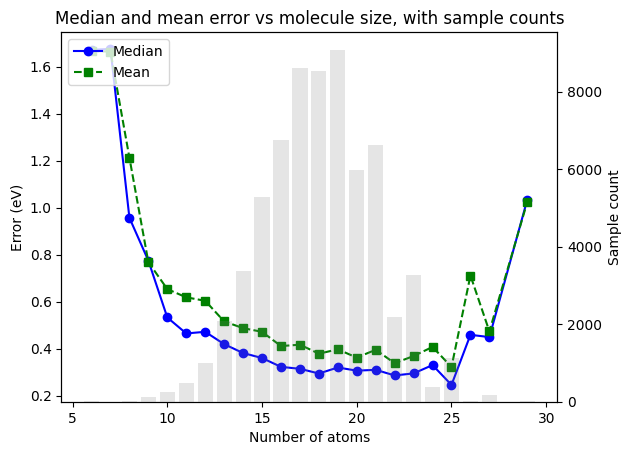

In [16]:
median_error_by_size = combined_df.groupby('num_atoms')['error'].median()
mean_error_by_size = combined_df.groupby('num_atoms')['error'].mean()
counts_by_size = combined_df.groupby('num_atoms').size()

fig, ax1 = plt.subplots()

ax1.plot(median_error_by_size.index, median_error_by_size.values, marker='o', color='blue', label='Median')
ax1.plot(mean_error_by_size.index, mean_error_by_size.values, marker='s', color='green', linestyle='--', label='Mean')
ax1.set_ylabel('Error (eV)')
ax1.set_xlabel('Number of atoms')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar(counts_by_size.index, counts_by_size.values, alpha=0.2, color='gray')
ax2.set_ylabel('Sample count')

plt.title('Median and mean error vs molecule size, with sample counts')
plt.savefig('docs/results/error_vs_size_full.png')

The graph shows that molecules with the smallest and biggest amounth of atoms have the highest error. 

This is expected since these molecule sizes are less represented in the dataset.

However, the results also suggest a general trend in which the error decreases as the number of atoms increases. 
This can be observed at size 25, which is the minimum of the error function but clearly has a small sample size.


## 3.  How does the error relate to the number of bonds and heteroatoms?

In [17]:
import matplotlib.pyplot as plt

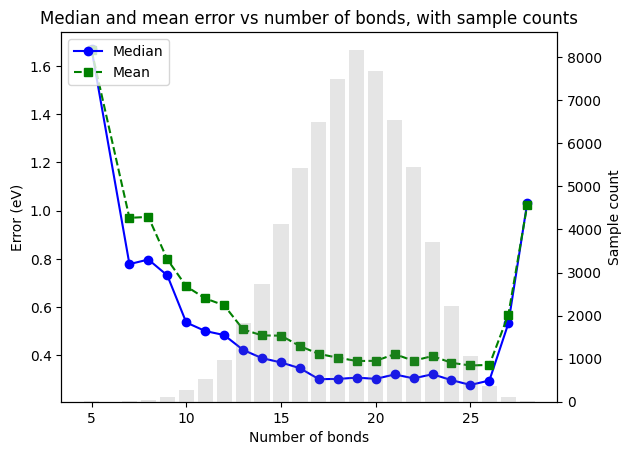

In [18]:
median_error_by_bonds = combined_df.groupby('num_bonds')['error'].median()
mean_error_by_bonds = combined_df.groupby('num_bonds')['error'].mean()
counts_by_bonds = combined_df.groupby('num_bonds').size()

fig, ax1 = plt.subplots()
ax1.plot(median_error_by_bonds.index, median_error_by_bonds.values, marker='o', color='blue', label='Median')
ax1.plot(mean_error_by_bonds.index, mean_error_by_bonds.values, marker='s', color='green', linestyle='--', label='Mean')
ax1.set_ylabel('Error (eV)')
ax1.set_xlabel('Number of bonds')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar(counts_by_bonds.index, counts_by_bonds.values, alpha=0.2, color='gray')
ax2.set_ylabel('Sample count')

plt.title('Median and mean error vs number of bonds, with sample counts')
plt.savefig('docs/results/error_vs_bonds_full.png')

This graph shows similar results as the number of atoms vs error graph.

The highest errors are situated at the extremes, but there is possibly a decreasing tendency at the middle
with 25 number of bonds giving the minimum error

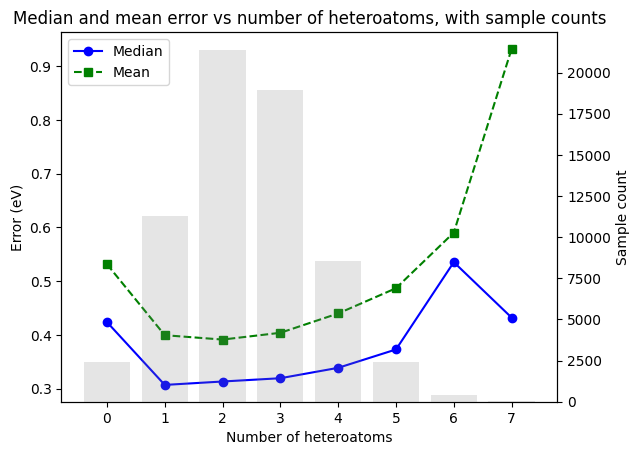

In [19]:
median_error_by_het = combined_df.groupby('num_heteroatoms')['error'].median()
mean_error_by_het = combined_df.groupby('num_heteroatoms')['error'].mean()
counts_by_het = combined_df.groupby('num_heteroatoms').size()

fig, ax1 = plt.subplots()
ax1.plot(median_error_by_het.index, median_error_by_het.values, marker='o', color='blue', label='Median')
ax1.plot(mean_error_by_het.index, mean_error_by_het.values, marker='s', color='green', linestyle='--', label='Mean')
ax1.set_ylabel('Error (eV)')
ax1.set_xlabel('Number of heteroatoms')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar(counts_by_het.index, counts_by_het.values, alpha=0.2, color='gray')
ax2.set_ylabel('Sample count')

plt.title('Median and mean error vs number of heteroatoms, with sample counts')
plt.savefig('docs/results/error_vs_heteroatoms_full.png')

This graph shows that molecules containing between one and four heteroatoms tend to have lower and more stable prediction errors. 

Molecules with no heteroatoms or with a high number of heteroatoms show larger errors. 

However, the results for molecules with six or seven heteroatoms should be interpreted with caution, as these groups are poorly represented in the dataset and are therefore more sensitive to outliers.

In [20]:
from analysis.error_utils import outlier_rate

In [21]:
rates_bonds = combined_df.groupby('num_bonds').apply(outlier_rate)
rates_het = combined_df.groupby('num_heteroatoms').apply(outlier_rate)

## 4. Are error patterns robust to different model initializations?

First we will build a correlation matrix for the signed error and absolute error

In [22]:
signed_error_matrix = combined_df.pivot(
    index='index',
    columns='run_id',
    values='signed_error'
)

absolute_error_matrix = combined_df.pivot(
    index='index',
    columns='run_id',
    values='error'
)

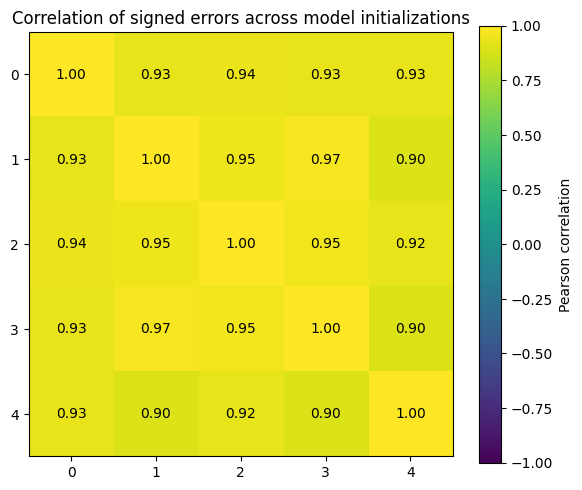

In [23]:
signed_corr = signed_error_matrix.corr()

plt.figure(figsize=(6, 5))
plt.imshow(signed_corr, vmin=-1, vmax=1)
plt.colorbar(label='Pearson correlation')

plt.xticks(
    range(len(signed_corr.columns)),
    signed_corr.columns
)

plt.yticks(
    range(len(signed_corr.index)),
    signed_corr.index
)

plt.title('Correlation of signed errors across model initializations')

for i in range(len(signed_corr)):
    for j in range(len(signed_corr)):
        plt.text(
            j,
            i,
            f'{signed_corr.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.tight_layout()
plt.savefig(
    'docs/results/signed_error_correlation.png',
    dpi=300
)
plt.show()

The value of each cell is close to 1 (r = 0.90-0.97). This indicates that each model makes similar mistakes on the same direction.

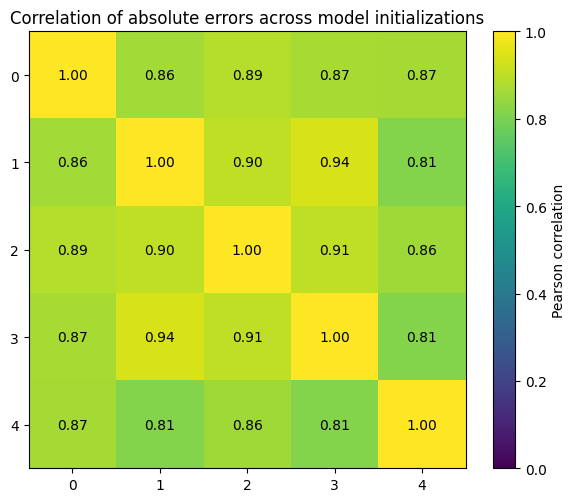

In [24]:
absolute_corr = absolute_error_matrix.corr()

plt.figure(figsize=(6, 5))
plt.imshow(absolute_corr, vmin=0, vmax=1)
plt.colorbar(label='Pearson correlation')

plt.xticks(
    range(len(absolute_corr.columns)),
    absolute_corr.columns
)

plt.yticks(
    range(len(absolute_corr.index)),
    absolute_corr.index
)

plt.title('Correlation of absolute errors across model initializations')

for i in range(len(absolute_corr)):
    for j in range(len(absolute_corr)):
        plt.text(
            j,
            i,
            f'{absolute_corr.iloc[i, j]:.2f}',
            ha='center',
            va='center'
        )

plt.tight_layout()
plt.savefig(
    'docs/results/absolute_error_correlation.png',
    dpi=300
)
plt.show()

Absolute prediction errors are also strongly correlated across model initializations (r=0.81-0.91) suggesting that the same molecules consistently represent challenging cases across models.

We can sum up this results using de Pearson and Spearm coefficients:

In [25]:
import numpy as np

In [26]:
signed_corr_spearman = signed_error_matrix.corr(method='spearman')

absolute_corr_spearman = absolute_error_matrix.corr(method='spearman')

In [27]:
def mean_off_diagonal(corr_matrix):
    mask = ~np.eye(corr_matrix.shape[0], dtype=bool)
    return corr_matrix.where(mask).stack().mean()

print(
    "Mean Pearson correlation of signed errors:",
    mean_off_diagonal(signed_corr)
)

print(
    "Mean Pearson correlation of absolute errors:",
    mean_off_diagonal(absolute_corr)
)

print(
    "Mean Spearman correlation of signed errors:",
    mean_off_diagonal(signed_corr_spearman)
)

print(
    "Mean Spearman correlation of absolute errors:",
    mean_off_diagonal(absolute_corr_spearman)
)

Mean Pearson correlation of signed errors: 0.9328562981530057
Mean Pearson correlation of absolute errors: 0.8721160677519759
Mean Spearman correlation of signed errors: 0.9241970816616313
Mean Spearman correlation of absolute errors: 0.7939609801014987


Finally, we will check for each molecule how many models have classified it as an outlier

In [28]:
import pandas as pd

In [29]:
outlier_matrix = pd.DataFrame(
    False,
    index=absolute_error_matrix.index,
    columns=absolute_error_matrix.columns
)

thresholds = {}

for model in absolute_error_matrix.columns:

    q1 = absolute_error_matrix[model].quantile(0.25)
    q3 = absolute_error_matrix[model].quantile(0.75)

    iqr = q3 - q1
    threshold = q3 + 1.5 * iqr

    thresholds[model] = threshold

    outlier_matrix[model] = (
        absolute_error_matrix[model] > threshold
    )

In [30]:
outlier_counts = outlier_matrix.sum(axis=1)

print(outlier_counts.value_counts().sort_index())

0    12287
1      213
2      154
3      106
4      100
5      224
Name: count, dtype: int64


There are a lot of molecules that have been classified as an outlier by only one model, and a considerable amounth by 2 to 4 models. 

This indicates that not all outliers are equally robust

## 5. What portion of the total error is systemic?

First we will compare how hard is a molecule gap to predict for each model with how systemic the error is.

In [31]:
per_molecule = pd.DataFrame({
    'mean_signed_error': signed_error_matrix.mean(axis=1),
    'mean_absolute_error': absolute_error_matrix.mean(axis=1),
    'std_signed_error': signed_error_matrix.std(axis=1),
    'std_absolute_error': absolute_error_matrix.std(axis=1)
})

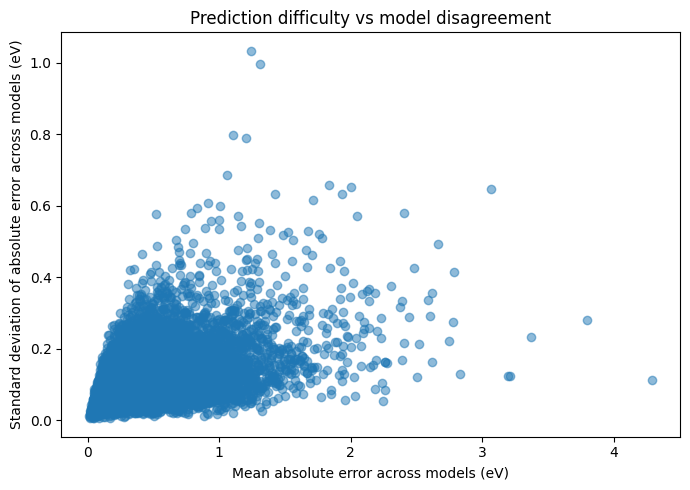

In [32]:
plt.figure(figsize=(7, 5))

plt.scatter(
    per_molecule['mean_absolute_error'],
    per_molecule['std_absolute_error'],
    alpha=0.5
)

plt.xlabel('Mean absolute error across models (eV)')
plt.ylabel('Standard deviation of absolute error across models (eV)')

plt.title('Prediction difficulty vs model disagreement')

plt.tight_layout()

plt.savefig(
    'docs/results/error_vs_model_disagreement.png',
    dpi=300
)

plt.show()

This graph shows the relation between prediction difficulty and disagreement across models

We can see that a bigger MAE increseas the standard deviation between models, meaning that if a molecule gap is hard to predict for the models, their prediction will differ more between them.

Now we will decompose the error variance to determine whether error patterns are mainly driven by differences between molecules or by variability across model initializations.

In [33]:
from analysis.error_utils import variance_decomposition

In [34]:
signed_decomposition = variance_decomposition(
    signed_error_matrix
)

absolute_decomposition = variance_decomposition(
    absolute_error_matrix
)

print('SIGNED ERROR')
for key, value in signed_decomposition.items():
    print(f'{key}: {value:.4f}')

print('\nABSOLUTE ERROR')
for key, value in absolute_decomposition.items():
    print(f'{key}: {value:.4f}')

SIGNED ERROR
total_variation: 19761.4285
between_molecule: 18660.7204
within_molecule: 1100.7081
systematic_fraction: 0.9443
model_specific_fraction: 0.0557

ABSOLUTE ERROR
total_variation: 8631.2708
between_molecule: 7715.6566
within_molecule: 915.6142
systematic_fraction: 0.8939
model_specific_fraction: 0.1061


The variance decomposition shows that the error is predominantly molecule-dependent. The between-molecule component accounts for 94.4% of the variance in signed errors and 89.4% in absolute errors, while only 5.6% and 10.6%, respectively, are associated with model-specific variation.

This suggests that the main source of error is not random variation caused by model initialization, but systematic differences in how well the GNN predicts different molecular structures.

## 6. Do different chemical families present different errors?

In [35]:
import seaborn as sns
from analysis.error_utils import add_chemical_family, add_fragment_features, analyze_fragments
from evaluation.checkpoint import load_model_from_checkpoint

In [36]:
first_model_path = experiment_results['200_epochs'][0]['model_path']

bundle = load_model_from_checkpoint(first_model_path)

combined_df = add_chemical_family(combined_df, bundle['test_data'])

c:\Users\ericp\Desktop\Biblioteca\projects\Molecule_property_prediction_GNN\evaluation\checkpoint.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load

First we will compare the prediction error across different molecule families

family
acyclic            6515
aliphatic_ring    47195
aromatic          10695
dtype: int64
family
acyclic           0.047583
aliphatic_ring    0.032376
aromatic          0.040299
dtype: float64


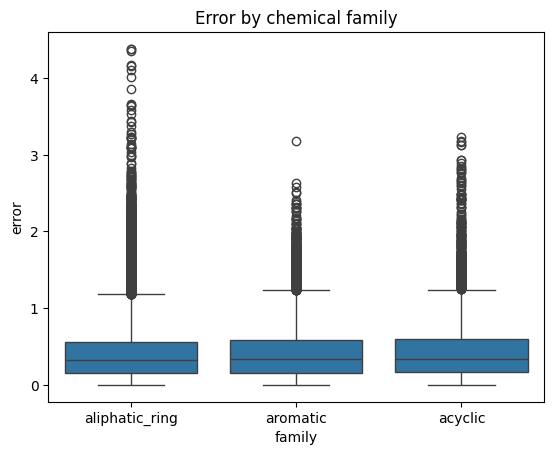

In [37]:
sns.boxplot(x='family', y='error', data=combined_df)
plt.title('Error by chemical family')
plt.savefig('docs/results/error_vs_family_boxplot.png')

counts_family = combined_df.groupby('family').size()
rates_family = combined_df.groupby('family').apply(outlier_rate)
print(counts_family)
print(rates_family)

The boxplot shows no meaningful difference in error distribution across chemical families (acyclic, aliphatic ring, aromatic) since medians and interquantile ranges are nearly identical. 

This is consistent with earlier findings (heteroatom count, molecule size) where coarse structural categories fail to explain prediction difficulty

To go beyond coarse structural categories, we scan ~85 RDKit functional group descriptors and compare mean error between molecules with and without each fragment, filtering groups with enough sample size (n>=100)

In [38]:
combined_df = add_fragment_features(combined_df, bundle['test_data'])

[14:29:42] Explicit valence for atom # 3 C, 4, is greater than permitted
[14:29:42] Explicit valence for atom # 4 C, 5, is greater than permitted
[14:29:42] Explicit valence for atom # 4 C, 5, is greater than permitted
[14:29:42] Explicit valence for atom # 4 C, 4, is greater than permitted
[14:29:42] Explicit valence for atom # 5 C, 5, is greater than permitted
[14:29:42] Explicit valence for atom # 5 C, 5, is greater than permitted
[14:29:42] Explicit valence for atom # 4 C, 4, is greater than permitted
[14:29:42] Explicit valence for atom # 5 C, 5, is greater than permitted
[14:29:42] Explicit valence for atom # 5 C, 5, is greater than permitted
[14:29:42] Explicit valence for atom # 3 C, 4, is greater than permitted
[14:29:43] Explicit valence for atom # 4 C, 5, is greater than permitted
[14:29:43] Explicit valence for atom # 5 C, 5, is greater than permitted
[14:29:43] Explicit valence for atom # 4 C, 5, is greater than permitted
[14:29:43] Explicit valence for atom # 5 C, 5, is g

In [39]:
fragment_fns = [c for c in combined_df.columns if c.startswith('fr_')]
fragment_results = analyze_fragments(combined_df, fragment_fns, min_count=100)
print(fragment_results)

              fragment  n_with  mean_error_with  mean_error_without      diff
0            fr_Al_COO     100         1.311092            0.411355  0.899738
7               fr_COO     105         1.260242            0.411367  0.848874
8              fr_COO2     105         1.260242            0.411367  0.848874
20         fr_aldehyde    6580         0.652025            0.385970  0.266055
34          fr_guanido     105         0.565142            0.412485  0.152657
22     fr_alkyl_halide     320         0.560576            0.412003  0.148573
39   fr_ketone_Topliss    6840         0.534066            0.398562  0.135504
38           fr_ketone    7390         0.527539            0.398109  0.129430
10        fr_C_O_noCOO   22135         0.482120            0.377245  0.104874
9               fr_C_O   22135         0.482120            0.377245  0.104874
23     fr_allylic_oxid    3755         0.507449            0.406962  0.100487
28          fr_benzene     120         0.504952            0.412

Results span a continous range from diff=0.90 to diff=-0.08, with most fragments clustering near zero.

The largest positive differences (or harder-than-average cases) like fr_Al_COO, fr_COO, fr_COO2 with diff ~ 0.85-0.90 have small sample sizes and should be treated cautiously. More reliable signals come from well-sampled oxygen-containing groups, like fr_aldehyde (n= 6580, diff=0.27) and fr_ketone (n=7390, diff=0.13), and fr_C_O (n=22 135, diff=0.10) all showing a consistent and modest association between carbonyl-type groups and higher error.

No fragments show a comparable large negative association (easier-than-average cases), and most alcohol-related fragments (fr_Al_OH, fr_Al_OH_noTert) show small negative diffs, suggesting they are midly easier than average